# Loan Approval Prediction

This project explores a loan application dataset and develops a machine learning model to predict whether a loan application will be approved based on applicant demographics, financial information, and credit history.

The workflow includes data exploration, preprocessing, missing value treatment, feature encoding, model training, and evaluation using Logistic Regression.


## LOADING THE DATASET 

## 1. Import the required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import sklearn.preprocessing as preprocessing
from pathlib import Path
from sklearn.metrics import roc_auc_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from tabulate import tabulate
from sklearn import metrics
from sklearn.metrics import confusion_matrix,  classification_report

## 2. Read the dataset

In [2]:
data_dir = Path('../../Data')
data_file = data_dir / 'Loan.csv'
data = pd.read_csv(data_file)

## 3. Get basic information about the dataset

#### 3a. Print dimensions of the dataset

In [3]:
print(data.shape)

(614, 13)


#### 3b. Print the column names

In [4]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

#### 3c. Print the first five observations

In [5]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


#### 3d. Print summary of the dataset using the info() function

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## EXPLORATORY DATA ANALYSIS

## 1. Univariate exploratory data analysis

> __COUNTPLOT:__ A countplot shows the number of occurrences of each value (category) in the data.

> __seaborn.countplot()__ method is used to show the counts of observations in each category using bars.

#### 1a. Plot a countplot of "Credit_History" 

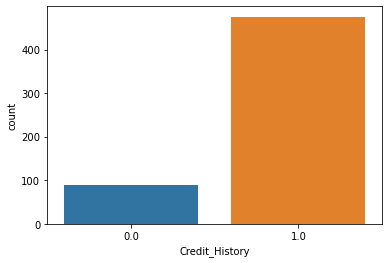

In [7]:
sns.countplot(x="Credit_History", data=data)
plt.show()

#### 1b. Plot a countplot of "Married" 

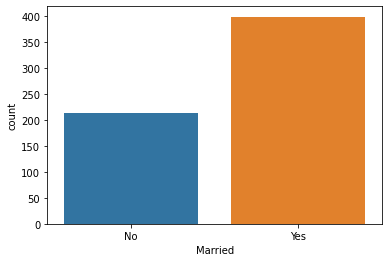

In [8]:
sns.countplot(x="Married", data=data)
plt.show()

#### 1c. Plot a countplot of "Education" 

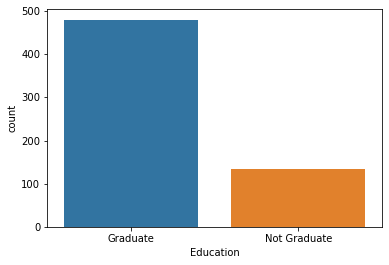

In [9]:
sns.countplot(x="Education", data=data)
plt.show()

#### 1d. Plot a countplot of "Dependents" 

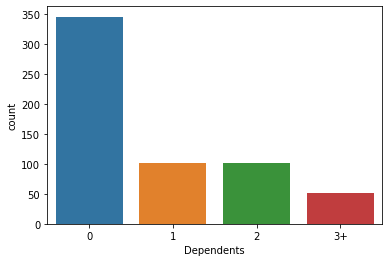

In [10]:
sns.countplot(x="Dependents", data=data)
plt.show()

## 2. Multivariate exploratory data analysis

> __BOXPLOT:__ A boxplot is a standardized way of displaying the distribution of data based on:
- The minimum value
- First quartile (Q1)
- Median
- Third quartile (Q3)
- The maximum value

> It can tell you about your outliers and what their values are. It can also tell you if your data is symmetrical, how tightly your data is grouped, and the skewness of your data

#### 2a. Plot a boxplot of Loan Status (x) and Loan Amount (y) with and without outliers

<AxesSubplot:xlabel='Loan_Status', ylabel='LoanAmount'>

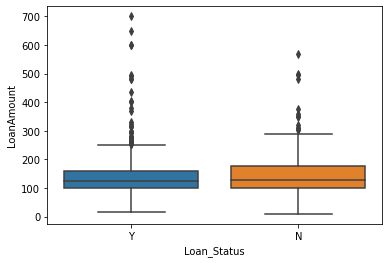

In [11]:
sns.boxplot(x="Loan_Status", y="LoanAmount", data=data, showfliers=True)

<AxesSubplot:xlabel='Loan_Status', ylabel='LoanAmount'>

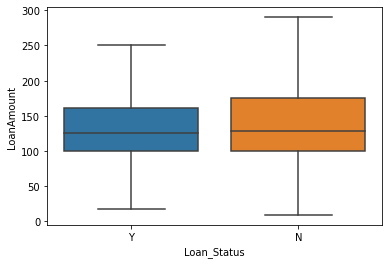

In [12]:
sns.boxplot(x="Loan_Status", y="LoanAmount", data=data, showfliers=False)

#### 2b. Plot a boxplot of Loan Status (x) and Applicant Income (y)

<AxesSubplot:xlabel='Loan_Status', ylabel='ApplicantIncome'>

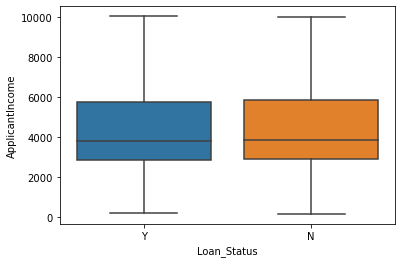

In [13]:
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data = data, showfliers=False)

#### 2c. Plot a boxplot of Loan Status (x) and Coapplicant Income (y)

<AxesSubplot:xlabel='Loan_Status', ylabel='CoapplicantIncome'>

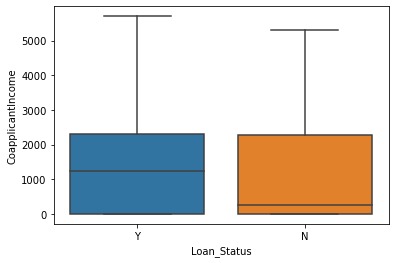

In [14]:
sns.boxplot(x="Loan_Status", y="CoapplicantIncome", data=data, showfliers=False)

## 3. Print a heatmap with correlations of the numerical variables

<AxesSubplot:>

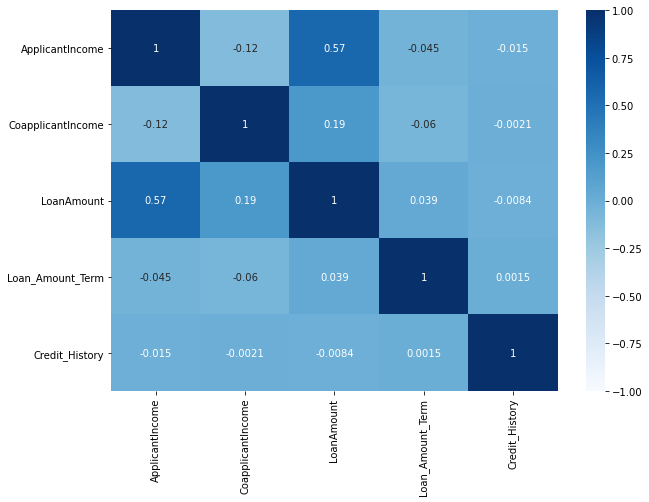

In [15]:
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot=True, vmin=-1.0, vmax=1.0, cmap="Blues")

## DATA PREPARATION

## 1. Defining numerical and categorical features

#### 1a. Assign numerical variables to the variable "num_features"

> The numerical variables are: 
- Dependents
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term

In [16]:
num_features = ['Dependents','ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']

#### 1b. Assign categorical variables to the variable "cat_features"
> The categorical variables are:
- Gender
- Married
- Education
- Credit_History
- Property_Area
- Self_Employed

In [17]:
cat_features = ['Gender','Married','Education','Credit_History','Property_Area', 'Self_Employed']

## 2. Changing datatypes of certain columns

#### 2a. Print the unique values in the column "Dependents"

In [18]:
data['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

#### 2b. Replace the strings '0', '1', '2', '3+' with numeric values 0, 1, 2 and 3
> 'Dependents' is a numeric variable column. But you can see that it has string datatype as its values. So you need to convert those values to numbers to get a numeric variable. 

In [19]:
data['Dependents'] = data['Dependents'].replace(to_replace=['0', '1', '2', '3+'], value=[0, 1, 2, 3])

#### 2c. Now print the unique values in the column "Dependents" again.
> You should see the values you have specified, that is, 0, 1, 2, 3

In [20]:
data['Dependents'].unique()

array([ 0.,  1.,  2.,  3., nan])

#### 2d. Print the unique values in the column "Credit_History"

> 'Credit_History' is a categorical variable column. But you can see that it has numeric values. So you need to convert those values to strings.

In [21]:
data['Credit_History'].unique()

array([ 1.,  0., nan])

#### 2e. Replace the string values '0' and '1' with the numerical values 0 and 1

In [22]:
data['Credit_History'] = data['Credit_History'].replace(to_replace=[1,0], value=['1','0'])

#### 2f. Now print the unique values in the column "Credit_History" again.
> The values should be '1', '0' and nan

In [23]:
data['Credit_History'].unique()

array(['1', '0', nan], dtype=object)

## 3. Missing value imputation

#### 3a. Print the number of missing values in each of the numerical variables

In [24]:
data[num_features].isnull().sum()

Dependents           15
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
dtype: int64

#### 3b. Impute the missing values of "Loan amount" with the median

> There is a large difference between mean and median because of the presence of outliers on the higher side. When the data is asymmetrical, median should be used to impute the missing values.

In [25]:
 data["LoanAmount"] = data["LoanAmount"].fillna(data["LoanAmount"].median())

#### 3c. Impute the missing values of "Dependents" with the mean

> Median is 0 as majority of the values in this variable are 0. So you should use mean to impute the missing values instead of the median.

In [26]:
 data["Dependents"] = data["Dependents"].fillna(data["Dependents"].mean())

#### 3d. Impute the missing values of "Loan_Amount_Term" with the value 360

> There are only a few discreet values in this variable. Large majority of values are 360. So you should replace the missing values with the most common value.

In [27]:
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(360)

#### 3e. Print the number of missing values in each of the categorical variables

In [28]:
data[cat_features].isnull().sum()

Gender            13
Married            3
Education          0
Credit_History    50
Property_Area      0
Self_Employed     32
dtype: int64

#### 3f. Impute the missing values of categorical variables by adding a new category called "Missing" 
> You can do it individually for each variable or use a __for__ loop. Check assignment instructions for how to use a for loop

In [29]:
for f in cat_features:
    data[f] = data[f].fillna('Missing')

#### 3g. Print the number of missing values in the dataset
> Since we have imputed the missing values, there should be no missing values in any of the features

In [30]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## 4. Feature Selection


#### 4a Assign the target and feature variables

In [31]:
features = num_features + cat_features
target = 'Loan_Status'

#### 4b. Assign the feature variable column to variable "X" and the target variable column to the variable "y"

In [32]:
X = data[features]
y = data[target]

## FITTING THE MODEL

## 1. Split data into train and test sets


#### 1a. Split the data into train and test sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

#### 1b. Print dimensions of the train and test sets

In [34]:
print("Dimensions of the train set are: ", X_train.shape)
print("Dimensions of the train set are: ", X_test.shape)

Dimensions of the train set are:  (429, 11)
Dimensions of the train set are:  (185, 11)


#### 1c. Print the relative frequencies of the unique values in "y_train" and "y_test"

In [35]:
print(f"The relative frequencies in y_train are:\n{y_train.value_counts(normalize=True)}" )
print(f"\nThe relative frequencies in y_train are:\n{y_test.value_counts(normalize=True)}")

The relative frequencies in y_train are:
Y    0.694639
N    0.305361
Name: Loan_Status, dtype: float64

The relative frequencies in y_train are:
Y    0.67027
N    0.32973
Name: Loan_Status, dtype: float64


## 2. One-Hot Encoding

> __Sparse matrix__: A sparse matrix is a matrix that is comprised of mostly 0s.


> Sparse matrices are distinct from matrices with mostly non-zero values, which are referred to as dense matrices. Using sparse matrices to store data that contains a large number of zero-valued elements can both save a significant amount of memory and speed up the processing of that data.

#### 2a. Create sparse matrices

In [36]:
# These lists will contain:
# 1. A sparse matrix for numerical variables.
# 2. A sparse matrix for each of the categorical variables.
# In the training and testing sets respectively
train_li = []
test_li = []

# This will contain the names of the features after one hot encoding
feature_li = []

> We need to create sparse matrices for numnerical variables as well. This is because we cannot train our model on some dense variables and some sparse variables at the same time.

In [37]:
#Numerical features
train_li.append(sp.csr_matrix(X_train[num_features].values))
test_li.append(sp.csr_matrix(X_test[num_features].values))
feature_li += num_features

#### 2b. Perform One-Hot encoding on the categorical features

In [38]:
# This is a vectorizer object which defines how the one hot encoding will be done
vectorizer = OneHotEncoder(handle_unknown='ignore')

for col in cat_features:
    # We do not want any information leaking from train set to test set. 
    # Hence, we use fit and transform on the training set and only transform on the testing set.
    train_li.append(vectorizer.fit_transform(X_train[[col]].values))
    test_li.append(vectorizer.transform(X_test[[col]].values))
    feature_li += [col+'_'+str(cat) for cat in vectorizer.categories_[0]]


#### 2c. Stack the sparse matrices horizontally
> We need to combine our lists on sparse matrices into a single sparse matrix.

In [39]:
X_train_sp = sp.hstack(train_li)
X_test_sp = sp.hstack(test_li)

#### 2d. Print the dimensions of X_train_sp and X_test_sp

In [40]:
print("Dimensions of X_train_sp are:", X_train_sp.shape)
print("Dimensions of X_test_sp are:", X_test_sp.shape)

Dimensions of X_train_sp are: (429, 22)
Dimensions of X_test_sp are: (185, 22)


## 3. Logistic regression

#### 3a. Fit the logistic regression model

In [41]:
model = LogisticRegression(max_iter =1000)
model.fit(X_train_sp, y_train)

LogisticRegression(max_iter=1000)

## 4. Majority Prediction

#### 4a. Fit the majority prediction model

> Here, the model predicts everything as the most common class.

In [42]:
majority_class = y_train.mode().iloc[0]
majority_class

'Y'

In [1]:
tr_pred_majority = [majority_class]*y_train.shape[0]
te_pred_majority = [majority_class]*y_test.shape[0]

NameError: name 'majority_class' is not defined

## 5. Random Prediction

#### 5a. Fit the random prediction model

> This is a binary classifier so the model predicts either Yes or No randomly.

In [44]:
tr_pred_random = np.random.choice(y_train.unique(), y_train.shape[0])
te_pred_random = np.random.choice(y_train.unique(), y_test.shape[0])

## 6. Model Evaluation

#### 6a. Assign probabiity estimates of the train set to "tr_prob" and probabiity estimates of the test set to "te_prob"

In [45]:
tr_prob = model.predict_proba(X_train_sp)[:,1]
te_prob = model.predict_proba(X_test_sp)[:,1]

#### 6b. Predict class labels for samples in the train set and assign it to "tr_pred"

In [46]:
tr_pred = model.predict(X_train_sp)

#### 6c. Predict class labels for samples in the test set and assign it to "te_pred"

In [47]:
te_pred = model.predict(X_test_sp)

#### 6d. Print accuracy of the train and test sets using with the logistic regression method
> Accuracy measures how many observations, both positive and negative, were correctly classified

In [48]:
print('Logistic regression accuracy of the train set is: ', accuracy_score(y_train, tr_pred).round(3))
print('Logistic regression accuracy of the test set is: ', accuracy_score(y_test, te_pred).round(3))

Logistic regression accuracy of the train set is:  0.821
Logistic regression accuracy of the test set is:  0.795


#### 6e. Print accuracy of the train and test sets with the majority prediction method

In [49]:
print('Majority prediction accuracy of the train set is: ', accuracy_score(y_train, tr_pred_majority).round(3))
print('Majority prediction accuracy of the test set is: ', accuracy_score(y_test, te_pred_majority).round(3))

Majority prediction accuracy of the train set is:  0.695
Majority prediction accuracy of the test set is:  0.67


#### 6f. Print accuracy of the train and test sets with the random prediction method

In [50]:
print('Random prediction accuracy of the train set is: ', accuracy_score(y_train, tr_pred_random).round(3))
print('Random prediction accuracy of the test set is: ', accuracy_score(y_test, te_pred_random).round(3))

Random prediction accuracy of the train set is:  0.478
Random prediction accuracy of the test set is:  0.508


## 7. Comparing the results

#### 7a. Print a table that shows the type of model and accuracy of the training and testing sets for the three models (logistic regression, majority prediction and random prediction)

In [51]:
log_train = accuracy_score(y_train, tr_pred).round(3)
log_test = accuracy_score(y_test, te_pred).round(3)

In [52]:
maj_train = accuracy_score(y_train, tr_pred_majority).round(3)
maj_test = accuracy_score(y_test, te_pred_majority).round(3)

In [53]:
rand_train = accuracy_score(y_train, tr_pred_random).round(3)
rand_test = accuracy_score(y_test, te_pred_random).round(3)

In [54]:
table = [['Model', 'Train set accuracy', 'Test set accuracy'], ['Logistic regression', log_train, log_test], ['Majority prediction', maj_train, maj_test], ['Random prediction', rand_train, rand_test]]

In [55]:
print(tabulate(table))

-------------------  ------------------  -----------------
Model                Train set accuracy  Test set accuracy
Logistic regression  0.821               0.795
Majority prediction  0.695               0.67
Random prediction    0.478               0.508
-------------------  ------------------  -----------------
